<a href="https://colab.research.google.com/github/fmuranda/Climate_Science./blob/main/Precipitation_Anomalies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

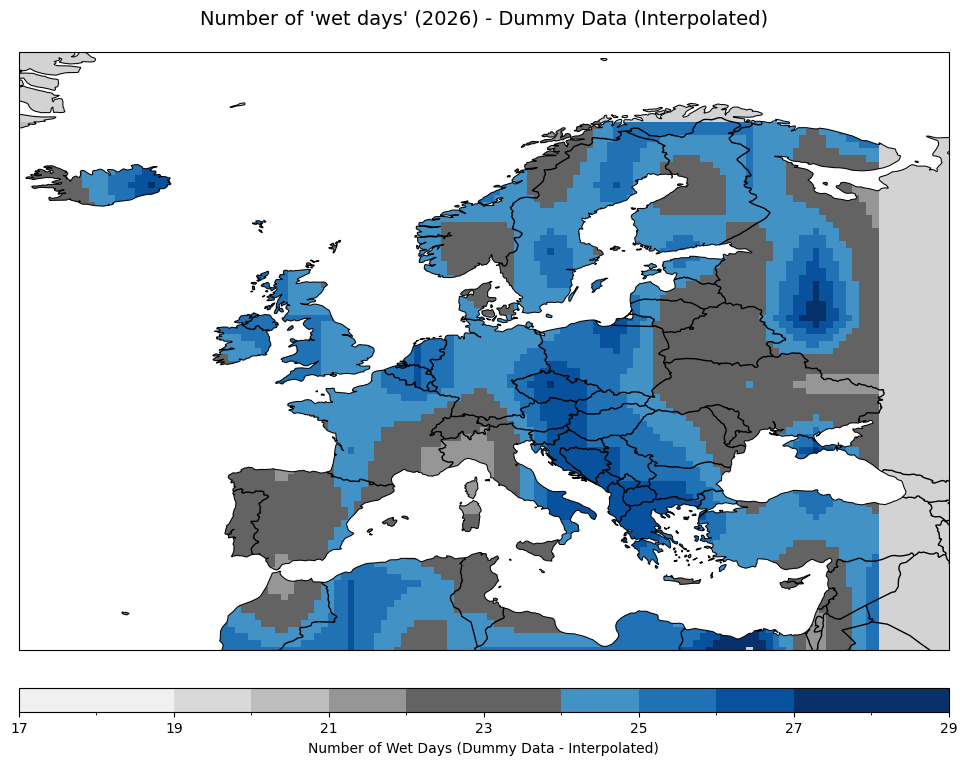

In [12]:
# To install cartopy, uncomment and run the following line:
!pip install cartopy

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import numpy as np # Import numpy for arange in interpolation

# 1. Load your ERA5 dataset (usually a .nc file)
ds = xr.open_dataset('era5_precipitation_2026.nc')

# 2. Define the 'Wet Day' logic
wet_days = (ds.tp > 0.001).sum(dim='time') # tp is total precipitation in meters

# To calculate the 'anomaly' (difference from the 1991-2020 mean), you would need
# to load a similar dataset for the 1991-2020 period and calculate its mean wet days.
# Then, anomaly = wet_days - mean_wet_days_1991_2020.
# For now, we will plot 'wet_days' directly as a placeholder.

# Interpolate the data to a finer grid to reduce pixelation
finer_lats = np.arange(ds['lat'].min(), ds['lat'].max(), 0.5) # Example: 0.5 degree resolution
finer_lons = np.arange(ds['lon'].min(), ds['lon'].max(), 0.5) # Example: 0.5 degree resolution
wet_days_interp = wet_days.interp(lat=finer_lats, lon=finer_lons, method='linear')

# 3. Define the custom blue and grey colormap
# Using a sequential colormap from a very light grey to a dark blue for 'wet days'
colors = ["#f0f0f0", "#d9d9d9", "#bdbdbd", "#969696", "#636363", "#4292c6", "#2171b5", "#08519c", "#08306b"]
cmap = ListedColormap(colors)

# 4. Setup the projection (Lambert Conformal is common for Europe)
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic context for better visual boundaries
ax.set_extent([-25, 45, 30, 75], crs=ccrs.PlateCarree()) # Focus on Europe
ax.add_feature(cfeature.LAND, facecolor='lightgray') # Fill land areas
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=1) # Set ocean facecolor to white to visually mask data in ocean areas
ax.add_feature(cfeature.COASTLINE, linewidth=0.75, edgecolor='black', zorder=2) # Stronger coastlines
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1, edgecolor='black', zorder=2) # Stronger country borders

# 5. Plot the interpolated data (drawn underneath the features that will mask the ocean)
plot = wet_days_interp.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    add_colorbar=False,
    levels=np.arange(wet_days.min().item(), wet_days.max().item() + 1, 1), # Adjust levels dynamically
    zorder=0 # Ensure data is plotted below land/ocean features
)

# 6. Add the horizontal colorbar at the bottom
cbar = plt.colorbar(plot, orientation='horizontal', pad=0.05, aspect=40)
cbar.set_label("Number of Wet Days (Dummy Data - Interpolated)")

plt.title("Number of 'wet days' (2026) - Dummy Data (Interpolated)", fontsize=14, pad=20)
plt.show()

In [6]:
import xarray as xr
import numpy as np
import pandas as pd

# Create dummy data for demonstration
# Define dimensions
times = pd.date_range("2026-01-01", "2026-01-30", freq="D")
lats = np.arange(30, 75, 5) # Example latitudes for Europe
lons = np.arange(-25, 45, 5) # Example longitudes for Europe

# Create a dummy 'tp' (total precipitation) variable
# Let's make some random precipitation values, with some days being 'wet' (tp > 0.001)
tp_data = np.random.rand(len(times), len(lats), len(lons)) * 0.005 # values between 0 and 0.005 meters
tp_data[tp_data < 0.0005] = 0 # Simulate some dry days

# Create an xarray DataArray
tp_da = xr.DataArray(
    tp_data,
    coords={'time': times, 'lat': lats, 'lon': lons},
    dims=['time', 'lat', 'lon'],
    name='tp',
    attrs={'units': 'm', 'long_name': 'Total precipitation'}
)

# Create an xarray Dataset
dummy_ds = xr.Dataset({"tp": tp_da})

# Save the dummy dataset to a .nc file
dummy_file_path = 'era5_precipitation_2026.nc'
dummy_ds.to_netcdf(dummy_file_path)

print(f"Dummy dataset saved to: {dummy_file_path}")
print(dummy_ds)

Dummy dataset saved to: era5_precipitation_2026.nc
<xarray.Dataset> Size: 31kB
Dimensions:  (time: 30, lat: 9, lon: 14)
Coordinates:
  * time     (time) datetime64[ns] 240B 2026-01-01 2026-01-02 ... 2026-01-30
  * lat      (lat) int64 72B 30 35 40 45 50 55 60 65 70
  * lon      (lon) int64 112B -25 -20 -15 -10 -5 0 5 10 15 20 25 30 35 40
Data variables:
    tp       (time, lat, lon) float64 30kB 0.004953 0.004034 ... 0.001224
